This notebook serves as a test for a fnl predictor on the elsner dataset. It follows the paper: "Towards detecting Primordial non-Gaussianity in the CMB using Spherical Convolutional Neural Networks" by Jorik Melsen and Thomas Floss.

# Model Tester

In [32]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import sys
import math
import logging
import healpy as hp
import numpy as np
from matplotlib import pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

from tensorflow.keras.layers import (  # type: ignore
    Dense,
    Dropout,
    Flatten,
    LeakyReLU,
    Permute,
)
from tensorflow.keras.callbacks import (  # type: ignore
    EarlyStopping,
    TerminateOnNaN,
    TensorBoard,
    ModelCheckpoint,
)
from tensorflow.keras.optimizers import Adam, AdamW  # type: ignore
from tensorflow.keras.optimizers.schedules import ExponentialDecay  # type: ignore
from tensorflow.keras.metrics import RootMeanSquaredError  # type: ignore
from tensorflow.data.experimental import assert_cardinality
from tensorflow.keras.initializers import HeNormal

from mlpng import Core
import mlpng.utils.plots as mplt
from mlpng.utils import (
    setup_logging,
    plot_predictions,
    plot_histogram,
    print_errors,
    plot_metrics,
    try_init_wandb,
)
from mlpng.utils.dataloaders import elsnerMapDataset, elsnerDataset, MapDataset

from deepsphere import HealpyGCNN
from deepsphere.healpy_layers import (
    HealpyChebyshev,
    HealpyPool,
)

keras = tf.keras

# Setup logging for notebook
setup_logging("mlpng.notebook", level=logging.DEBUG)
logger = logging.getLogger("mlpng.notebook")

In [34]:
print("Conda environment:", os.environ["CONDA_DEFAULT_ENV"])
print("Python executable:", sys.executable)
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")

Conda environment: ds25
Python executable: /users/stevensonb/.conda/envs/ds25/bin/python
TensorFlow version: 2.16.2
CUDA version: 12.3
cuDNN version: 8


In [35]:
# tf.keras.mixed_precision.set_global_policy("mixed_float16")

In [36]:
core = Core(
    ["settings/elsner.json", "--nsims", "1000"]
)  # , "--tensorboard", "--wandb"])

17-Mar-25 21:02:52 - mlpng.core - DEBUG - Parsing CLI args: ['settings/elsner.json', '--nsims', '1000']
17-Mar-25 21:02:52 - mlpng.core - INFO - Loading settings from file 'settings/elsner.json'
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1000 due to CLI
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.96
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Overriding cosmo param 'pivot_scalar' from 0.05 to 0.002
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.96,
    "pivot_scalar": 0.002,
    "H0": 70.1,
    "ombh2": 0.02256,
    "omch2": 0.1143,
    "tau": 0.084
  },
  "nsims": 1000,
  "nside": 128,
  "base_name": "elsner"
}
17-Mar-25 21:02:52 - mlpng.core - DEBUG - Found non-default value for 'nsims': 1000 (default: 100)
17-Mar-25 21:02:52 - mlpng.core - WARNING -

In [37]:
# train, val, test = elsnerDataset.fromCore(core, shapes=["local"]).split(
#     0.4, 0.1, 0.5, batch_size=1, to_tf=True
# )

# for alm, label in train.take(3):
#     alm = alm.numpy().astype(complex)
#     mplt.plot_cl_alm(core, alm[0], plot_camb=False, show=True, plot_func=plt.plot)

In [38]:
# ds = elsnerMapDataset.fromCore(core, shapes=["local"])
# train, val, test = ds.split(0.4, 0.1, 0.5, to_tf=False)
# train = train.to_tf()

# for sim, label in train.take(1):
#     s = sim.numpy()[0, :, 0]
#     print(min(s), max(s))
#     hp.mollview(s, nest=True, title=f"Sim {label.numpy()[0]}")

#     # Convert the map to a power spectrum (Cl)
#     s_ring = hp.reorder(s, n2r=True)
#     cl = hp.anafast(s_ring)  # , lmax=core.lmax)
#     ell = np.arange(len(cl))
#     print("found max ell:", len(cl))

#     # Plot the power spectrum
#     plt.figure()
#     plt.plot(ell, ell * (ell + 1) / (2 * np.pi) * cl)
#     plt.xlabel(r"$\ell$")
#     plt.ylabel(r"$C_\ell$")
#     plt.title(f"Power Spectrum (Cl) for Sim {label.numpy()[0]}")
#     plt.grid(True)
#     plt.show()

In [39]:
def get_model(input_shape, batch_size=32, n_y=1):
    nside = hp.npix2nside(input_shape[1])
    indices = np.arange(input_shape[1])
    layers = []

    n_layers = math.floor(math.log(nside, 2))
    for i in range(n_layers):
        fout = 32  # 2 ** (4 + i)
        layers.append(
            HealpyChebyshev(
                K=2,
                Fout=fout,
                # use_bias=True,
                use_bn=True,
                activation=LeakyReLU(0.3),
            )
        )
        layers.append(Dropout(0.1))
        layers.append(HealpyPool(1, "AVG"))

    layers.append(Flatten())
    layers.append(Dropout(0.3))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(32, activation=LeakyReLU(0.3)))
    layers.append(Dense(n_y))

    model = HealpyGCNN(
        nside,
        indices,
        layers,
        n_neighbors=8,
        max_batch_size=batch_size,
        initial_Fin=input_shape[-1],
    )

    model.build(input_shape)
    return model

In [40]:
max_epochs = 200
batch_size = 128
shapes = ["local"]  # , "equilateral", "orthogonal"]
epoch_steps = core.total_sims * 0.4 * 25 // batch_size + 1
print("epoch_steps:", epoch_steps)
decay_steps = epoch_steps * 1

# ds = MapDataset.fromCore(core, shapes=shapes)
ds = elsnerMapDataset.fromCore(core, shapes=shapes)

# the sizes and duplicates match the paper
train, val, test = ds.split(
    0.4,
    0.1,
    0.5,
    to_tf=True,
    batch_size=batch_size,
    duplicates=[25, 10, 2],
    cache_file=f"{core.name}-nb-noltrim",
)

# the paper does not rotate the test set
test.rotate = False

# this forces generation of the test dataset to cache, and we need it later
# this way by the time the first epoch finishes the dataset has been made, allowing for manual stopping of the notebook
test_y = np.concatenate([y for _, y in test])

strategy = tf.distribute.MirroredStrategy()
with strategy.scope():
    learning_rate = 5e-4
    learning_rate = ExponentialDecay(learning_rate, decay_steps, 0.95, staircase=True)
    # learning_rate = tf.keras.optimizers.schedules.CosineDecayRestarts(
    #     learning_rate, decay_steps * 3, m_mul=0.9
    # )

    model = get_model((None, core.npix, core.npols), batch_size, len(shapes))
    model.compile(
        optimizer=AdamW(learning_rate, weight_decay=0.1),  # type: ignore
        loss="mse",
        metrics=[RootMeanSquaredError()],  # type: ignore
    )

model.summary()

callbacks = [
    TerminateOnNaN(),
    EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, start_from_epoch=30
    ),
]
if core.use_tb:
    callbacks.append(
        TensorBoard(
            log_dir=f"{core.dirs['tb']}/{core.name}/{core.slurm.job}",
            histogram_freq=1,
            # write_images=True,
            write_steps_per_second=True,
        )
    )
if core.use_wandb:
    try_init_wandb(
        config={
            "batch_size": batch_size,
            "max_epochs": max_epochs,
        },
        dir=core.dirs["wandb"],
        append_to=callbacks,
        patch_tb=core.use_tb,
        patch_logdir=f"{core.dirs['tb']}/{core.name}/{core.slurm.job}",
    )

history = model.fit(
    train,
    epochs=max_epochs,
    validation_data=val,
    callbacks=callbacks,
    verbose=1,
)
# model.save(f"{core.dirs['model']}/{core.name}-{core.slurm.job}-jorik.keras")

epoch_steps: 79.0
17-Mar-25 21:02:52 - mlpng.utils.dataloaders - DEBUG - Splitting 'data/data/elsner_T_1000.hdf5' into train: 1:401, val: 401:501, test: 501:1001
17-Mar-25 21:02:52 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-train.cache


17-Mar-25 21:02:52 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-val.cache
17-Mar-25 21:02:52 - mlpng.utils.dataloaders - DEBUG - Using cache file: /lustre/smuexa01/client/users/stevensonb/tf_cache/elsner_T_1000-nb-noltrim-test.cache
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
17-Mar-25 21:02:52 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


Model: "healpy_gcnn_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chebyshev_21 (Chebyshev)        │ (None, 196608, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 196608, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_21 (HealpyPool)     │ (None, 49152, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_22 (Chebyshev)        │ (None, 49152, 32)      │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 49152, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_22 (HealpyPool)     │ (None, 12288, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_23 (Chebyshev)        │ (None, 12288, 32)      │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 12288, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_23 (HealpyPool)     │ (None, 3072, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_24 (Chebyshev)        │ (None, 3072, 32)       │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 3072, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_24 (HealpyPool)     │ (None, 768, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_25 (Chebyshev)        │ (None, 768, 32)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 768, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_25 (HealpyPool)     │ (None, 192, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_26 (Chebyshev)        │ (None, 192, 32)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 192, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_26 (HealpyPool)     │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chebyshev_27 (Chebyshev)        │ (None, 48, 32)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ healpy_pool_27 (HealpyPool)     │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,05

 Total params: 26,209 (102.38 KB)

 Trainable params: 25,761 (100.63 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 344ms/step - loss: 328262.6562 - root_mean_squared_error: 572.8467 - val_loss: 222688.5938 - val_root_mean_squared_error: 471.8989
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 341ms/step - loss: 189457.8750 - root_mean_squared_error: 433.6414 - val_loss: 37720.8555 - val_root_mean_squared_error: 194.2186
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 342ms/step - loss: 33710.9023 - root_mean_squared_error: 182.8034 - val_loss: 5743.6094 - val_root_mean_squared_error: 75.7866
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 341ms/step - loss: 8710.6777 - root_mean_squared_error: 93.2539 - val_loss: 5508.9014 - val_root_mean_squared_error: 74.2220
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 341ms/step - loss: 5625.3311 - root_mean_squared_error: 74.8846 - val_loss: 8621.7275 - val_root_mean_squared_error: 92.8533
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 342ms/step - loss: 5964.1035 - root_mean_squared_error: 77.1207 - val_loss: 5098.0679 - val_root_mean_sq

In [ ]:
logger.debug("Getting final plots")
preds = model.predict(test, verbose=1)
rmse = model.evaluate(test, verbose=1)[1]
# test_y = np.concatenate([y for _, y in test])  # type: ignore

17-Mar-25 21:30:48 - __main__ - DEBUG - Getting final plots
17-Mar-25 21:30:49 - tensorflow - WARNING - 5 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x153deaa11940> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 1100.4878 - root_mean_squared_error: 33.1671


17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - Standard deviation from fisher: 21.965457746395817, SEM: 0.6946087632679997
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - Mean error: 5.3109765, Median error: 5.907585
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - 49.9% (48.199999999999996, 50.9) are within 1 standard deviations
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - 83.1% (81.89999999999999, 84.3) are within 2 standard deviations
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - 94.8% (94.19999999999999, 95.3) are within 3 standard deviations
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - 98.9% (98.8, 99.1) are within 4 standard deviations
17-Mar-25 21:30:51 - mlpng.utils.utils - INFO - 99.8% (99.8, 99.9) are within 5 standard deviations


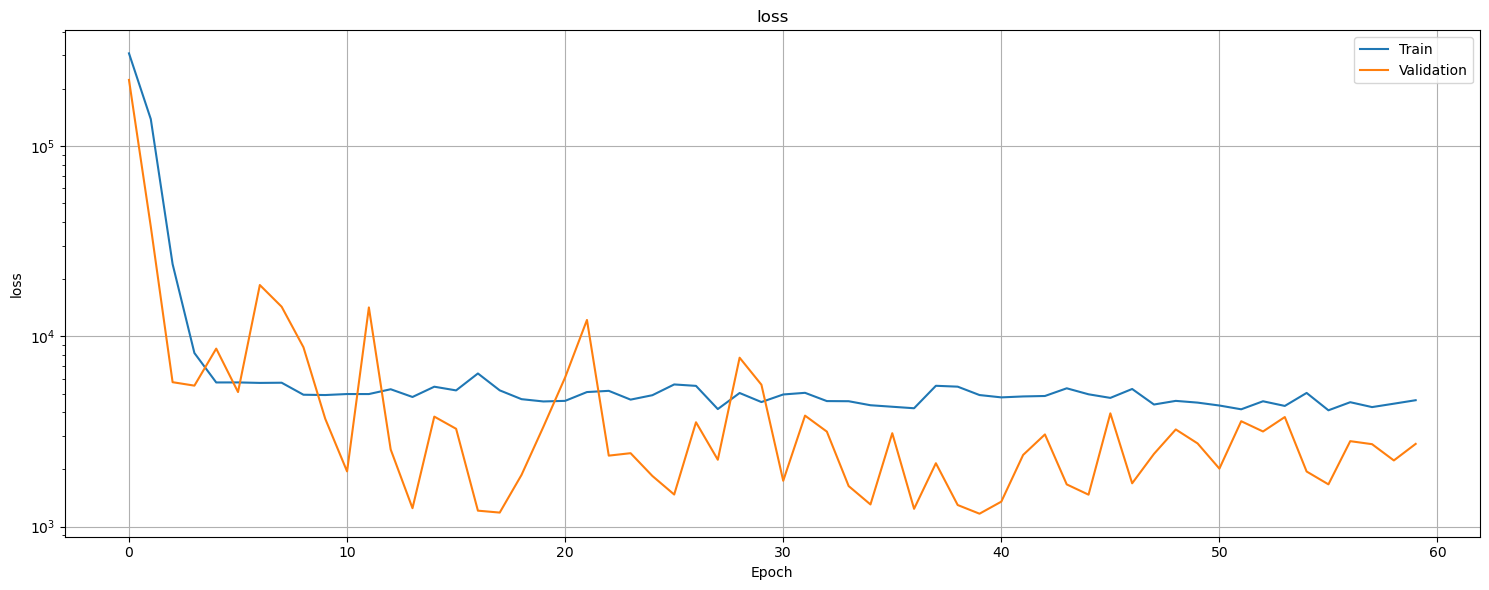

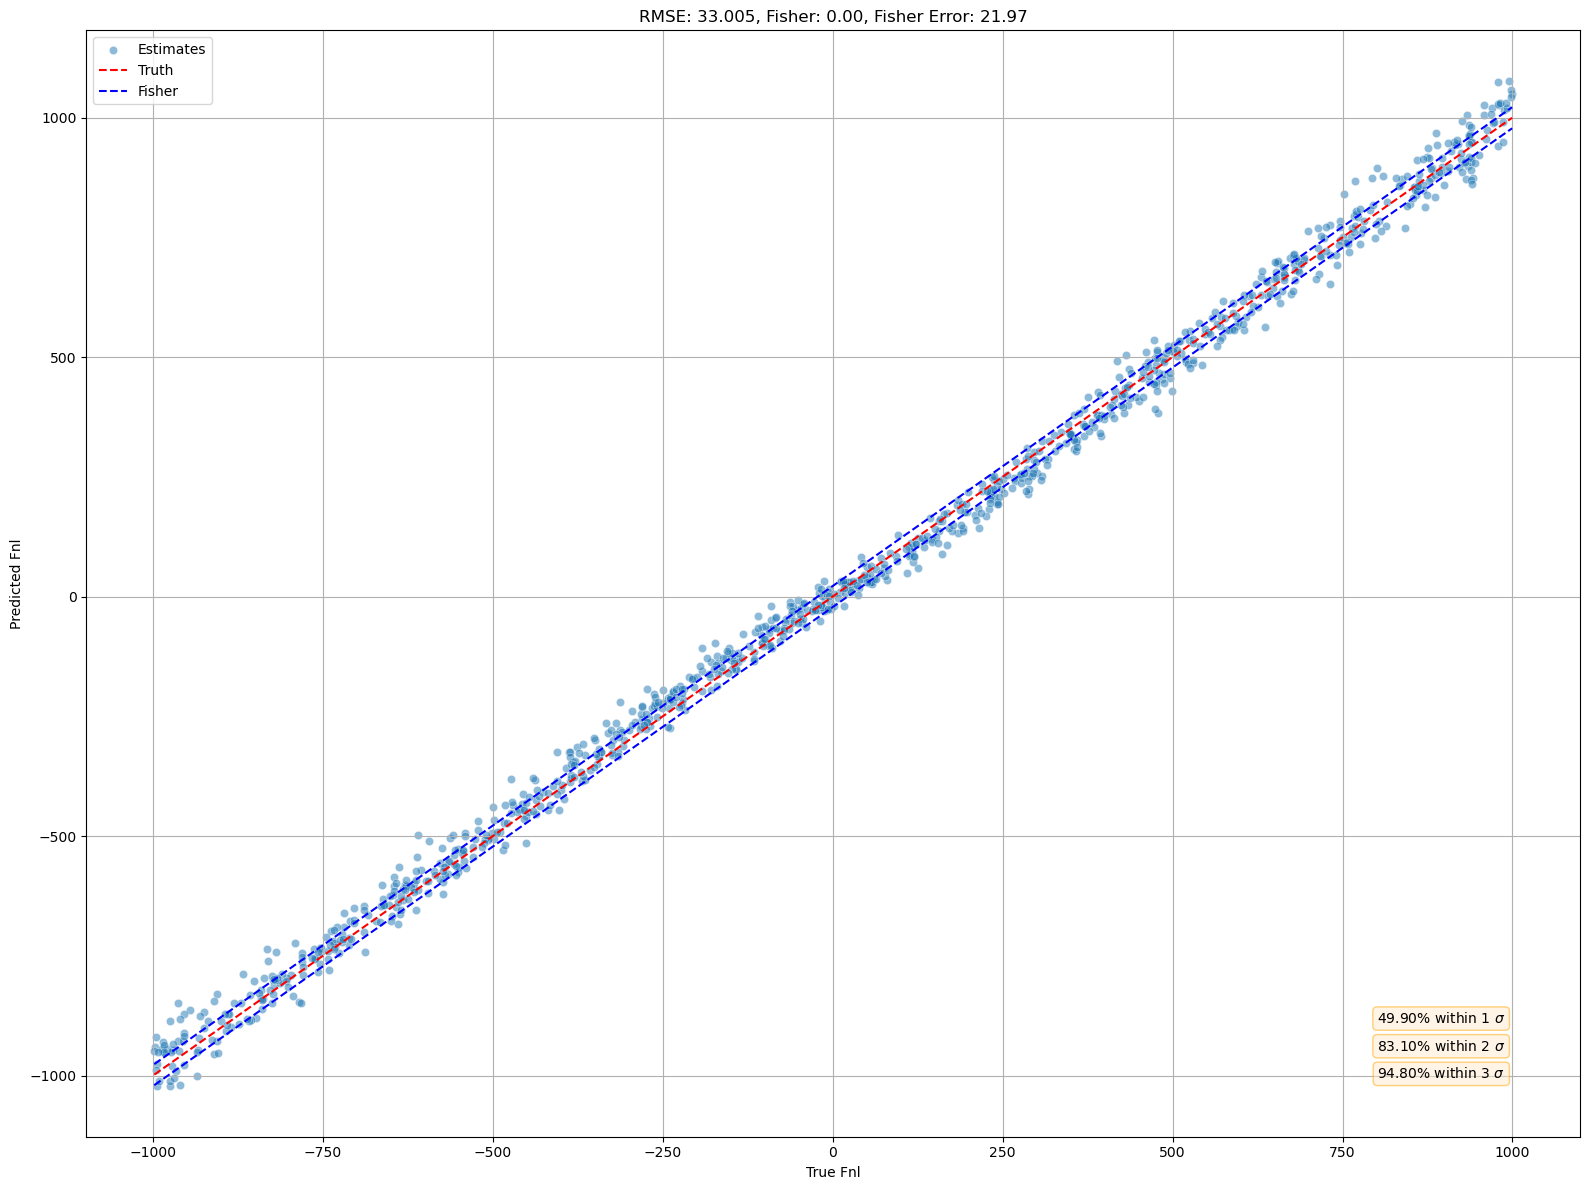

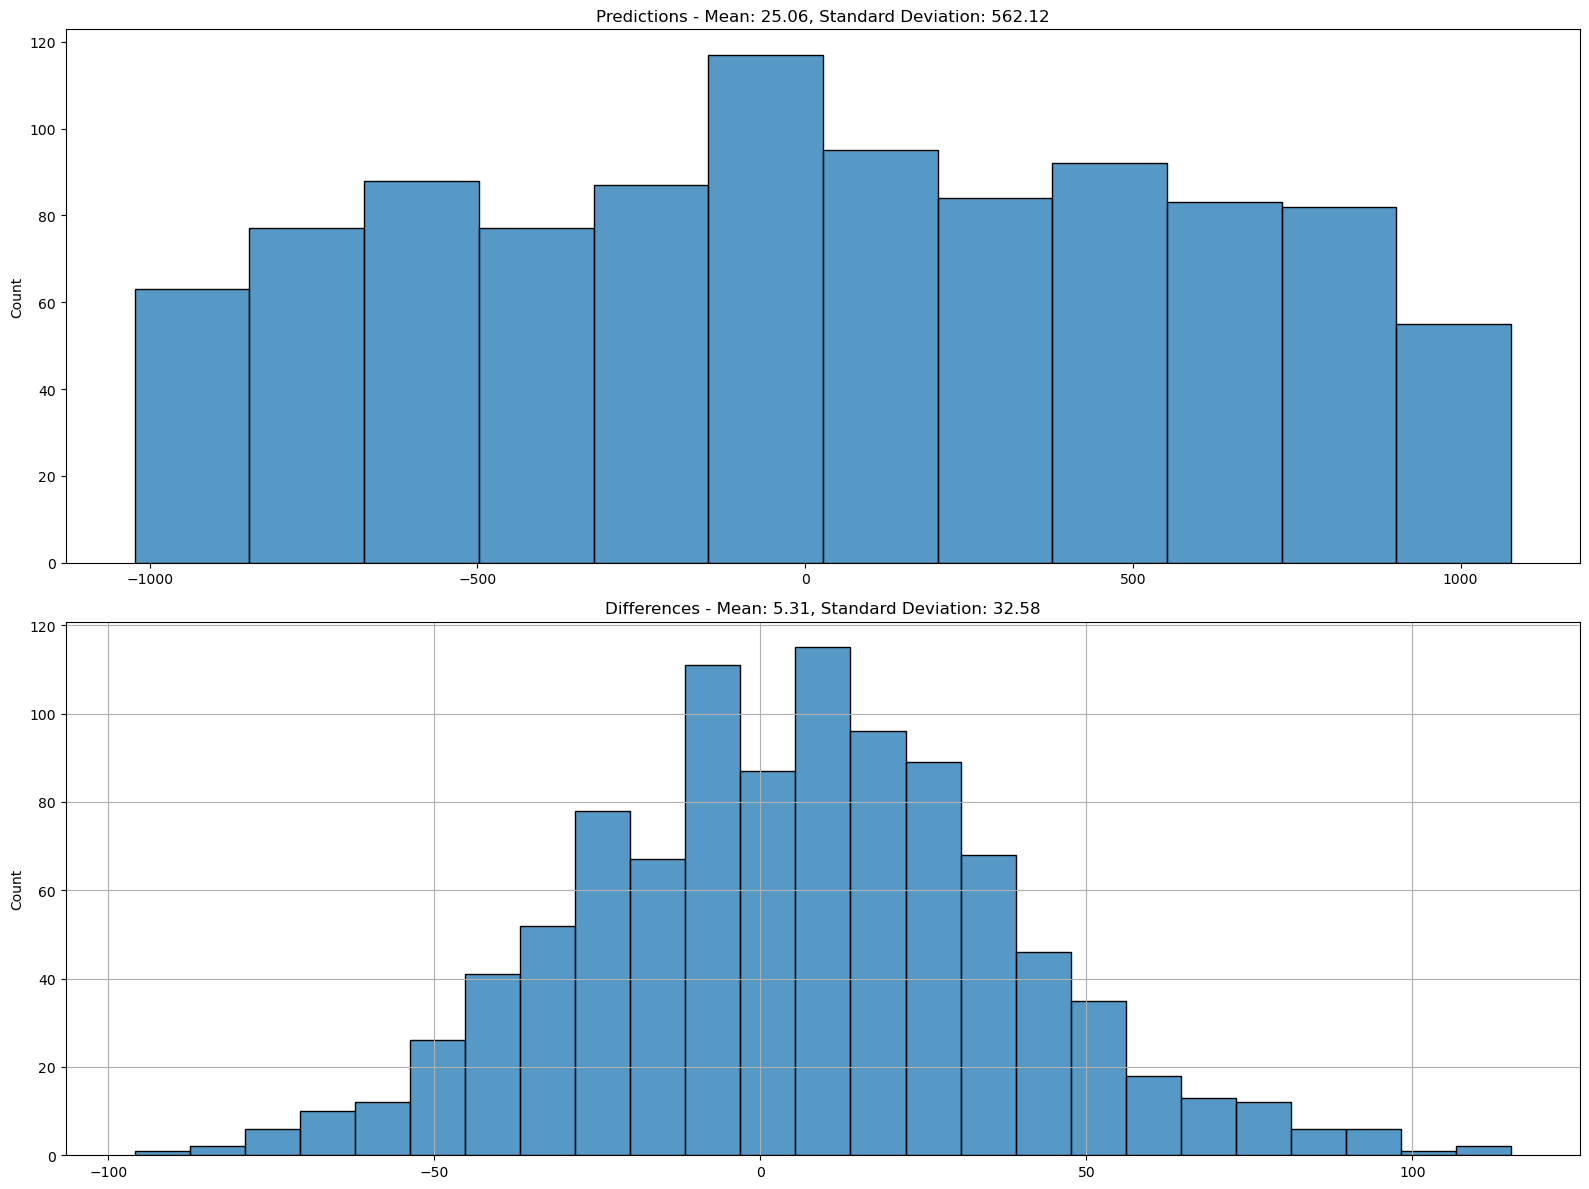

In [42]:
fisher = ds.get_fisher("local")
print_errors(test_y, preds, fisher)
plot_metrics(history, metrics=["loss"], show=True)
for shape in range(test_y.shape[1]):
    plot_predictions(
        test_y[:, shape],
        preds[:, shape],
        fisher=fisher,
        title=f"RMSE: {rmse:.3f}",
        show=True,
    )
    plot_histogram(test_y[:, shape], preds[:, shape], show=True)